In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [2]:
CO2KGperkwh_mineraldiesel = 0.26475  # 0.26808 is for CO2e
CO2KGperMJ_mineraldiesel = CO2KGperkwh_mineraldiesel / 3.6 
CO2KGperMJ_mineraldiesel
CO2KGperGJ_mineraldiesel = CO2KGperMJ_mineraldiesel * 1000
CO2KGperGJ_mineraldiesel

73.54166666666666

In [3]:
CO2KGperMJ_biodiesel_vegoil_UCO = 72.16 / 1000
CO2KGperGJ_biodiesel_vegoil_UCO = CO2KGperMJ_biodiesel_vegoil_UCO * 1000
CO2KGperGJ_biodiesel_vegoil_UCO

72.16

#### CH4+N2O as CO2e only around 1% of total scope1 CO2e (see below data source), we'll cutoff CH4/N2O due to lack of more accurate data

In [4]:
CH4KGperkg_alldiesel = 0.11 / 1000 / 0.84  
N2OKGperkg_alldiesel =  0.082/ 1000 / 0.84 

# MJ/kg --> pGWP_vs_GWP_ondiesel_per1000MJ.xlsx
CH4KGperMJ_mineraldiesel = CH4KGperkg_alldiesel / 42.8
N2OKGperMJ_mineraldiesel = N2OKGperkg_alldiesel / 42.8

CH4KGperMJ_biodiesel = CH4KGperkg_alldiesel / 39.9
N2OKGperMJ_biodiesel = N2OKGperkg_alldiesel / 39.9

CH4KGperGJ_mineraldiesel, N2OKGperGJ_mineraldiesel =  CH4KGperMJ_mineraldiesel*1000 ,  N2OKGperMJ_mineraldiesel * 1000
CH4KGperGJ_biodiesel, N2OKGperGJ_biodiesel =  CH4KGperMJ_biodiesel*1000 ,  N2OKGperMJ_biodiesel * 1000

print(CH4KGperGJ_biodiesel, N2OKGperGJ_biodiesel)
print(CH4KGperGJ_mineraldiesel, N2OKGperGJ_mineraldiesel)

0.003282014560210049 0.002446592672156582
0.0030596350689808638 0.0022808188696039166


### now add scope1 CO2 to scope3

In [4]:
# now let's grab scope 3 output datasheet, adding in scope1 for diesel / biodiesel, but only on selected types

data = pd.read_excel("diesel_output/twosets_pGWP_vs_GWP_ondiesel_per1000MJ.xlsx", sheet_name='plot', index_col = 0)

target_columns =  [
    'diesel, ecoinvent',
   # 'diesel, premise',
   # 'biodiesel, forest residues',
    'biodiesel, used cooking oil',
   # 'biodiesel, used cooking oil, with CCS',
    'biodiesel, rapeseed oil'
]

data2 = data[target_columns]
data2.head()

,"diesel, ecoinvent","biodiesel, used cooking oil","biodiesel, rapeseed oil"
premise GWP100,21.964023,-60.566544,-12.398170
"pGWP100 dpAGWP[CO2], SSP1-19, MY2030",20.524144,-60.901779,-20.001681
"pGWP100 dpAGWP[CO2], SSP1-19, MY2040",20.995844,-60.799281,-20.156658
"pGWP100 dpAGWP[CO2], SSP1-19, MY2050",21.130222,-60.771471,-20.698312
"pGWP100 dpAGWP[CO2], SSP2-45, MY2030",20.243045,-60.962128,-19.647134


In [6]:
# rename the existing columns to add "scope 3" suffix
data3 = data2.rename(columns={
    'diesel, ecoinvent': 'diesel, ecoinvent (scope 3)',
    'biodiesel, used cooking oil': 'biodiesel, used cooking oil (scope 3)',
    'biodiesel, rapeseed oil': 'biodiesel, rapeseed oil (scope 3)',
})

# add corresponding "scope 1" columns with fixed values
data3['diesel, ecoinvent (scope 1)'] = 73.54 
data3['biodiesel, used cooking oil (scope 1)'] = 72.16
data3['biodiesel, rapeseed oil (scope 1)'] = 72.16

data3

,"diesel, ecoinvent (scope 3)","biodiesel, used cooking oil (scope 3)","biodiesel, rapeseed oil (scope 3)","diesel, ecoinvent (scope 1)","biodiesel, used cooking oil (scope 1)","biodiesel, rapeseed oil (scope 1)"
premise GWP100,21.964023,-60.566544,-12.398170,73.54,72.16,72.16
"pGWP100 dpAGWP[CO2], SSP1-19, MY2030",20.524144,-60.901779,-20.001681,73.54,72.16,72.16
"pGWP100 dpAGWP[CO2], SSP1-19, MY2040",20.995844,-60.799281,-20.156658,73.54,72.16,72.16
"pGWP100 dpAGWP[CO2], SSP1-19, MY2050",21.130222,-60.771471,-20.698312,73.54,72.16,72.16
"pGWP100 dpAGWP[CO2], SSP2-45, MY2030",20.243045,-60.962128,-19.647134,73.54,72.16,72.16
"pGWP100 dpAGWP[CO2], SSP2-45, MY2040",20.844939,-60.828533,-18.840224,73.54,72.16,72.16
"pGWP100 dpAGWP[CO2], SSP2-45, MY2050",21.305781,-60.726098,-18.169821,73.54,72.16,72.16
"pGWP100 dpAGWP[CO2], SSP5-85, MY2030",19.821125,-61.053969,-19.565994,73.54,72.16,72.16
"pGWP100 dpAGWP[CO2], SSP5-85, MY2040",19.972237,-61.017463,-18.301742,73.54,72.16,72.16
"pGWP100 dpAGWP[CO2], SSP5-85, MY2050",20.683318,-60.857240,-16.492034,73.54,72.16,72.16


In [7]:
#  manually create MultiIndex column headers
multi_level_columns = pd.MultiIndex.from_tuples([
    ('diesel, ecoinvent', 'scope 3'),
    ('diesel, ecoinvent', 'scope 1'),
    ('biodiesel, used cooking oil', 'scope 3'),
    ('biodiesel, used cooking oil', 'scope 1'),
    ('biodiesel, rapeseed oil', 'scope 3'),
    ('biodiesel, rapeseed oil', 'scope 1'),
])

# final dataframe
df = pd.DataFrame({
    ('diesel, ecoinvent', 'scope 3'): data3['diesel, ecoinvent (scope 3)'],
    ('diesel, ecoinvent', 'scope 1'): data3['diesel, ecoinvent (scope 1)'],
    ('biodiesel, used cooking oil', 'scope 3'): data3['biodiesel, used cooking oil (scope 3)'],
    ('biodiesel, used cooking oil', 'scope 1'): data3['biodiesel, used cooking oil (scope 1)'],
    ('biodiesel, rapeseed oil', 'scope 3'): data3['biodiesel, rapeseed oil (scope 3)'],
    ('biodiesel, rapeseed oil', 'scope 1'): data3['biodiesel, rapeseed oil (scope 1)'],
}, index=data3.index)

# Apply MultiIndex
df.columns = multi_level_columns

df

diesel, ecoinvent          \
                                                   scope 3 scope 1   
premise GWP100                                   21.964023   73.54   
pGWP100 dpAGWP[CO2], SSP1-19, MY2030             20.524144   73.54   
pGWP100 dpAGWP[CO2], SSP1-19, MY2040             20.995844   73.54   
pGWP100 dpAGWP[CO2], SSP1-19, MY2050             21.130222   73.54   
pGWP100 dpAGWP[CO2], SSP2-45, MY2030             20.243045   73.54   
pGWP100 dpAGWP[CO2], SSP2-45, MY2040             20.844939   73.54   
pGWP100 dpAGWP[CO2], SSP2-45, MY2050             21.305781   73.54   
pGWP100 dpAGWP[CO2], SSP5-85, MY2030             19.821125   73.54   
pGWP100 dpAGWP[CO2], SSP5-85, MY2040             19.972237   73.54   
pGWP100 dpAGWP[CO2], SSP5-85, MY2050             20.683318   73.54   
pGWP100 fixed AGWP[CO2], SSP1-19, MY2030         23.498386   73.54   
pGWP100 fixed AGWP[CO2], SSP1-19, MY2040         23.796138   73.54   
pGWP100 fixed AGWP[CO2], SSP1-19, MY2050         24.063539   73.54   
pGWP100 fixed AGWP[CO2], SSP2-45, MY2030         22.655888   73.54   
pGWP100 fixed AGWP[CO2], SSP2-45, MY2040         21.964741   73.54   
pGWP100 fixed AGWP[CO2], SSP2-45, MY2050         21.223223   73.54   
pGWP100 fixed AGWP[CO2], SSP5-85, MY2030         21.820432   73.54   
pGWP100 fixed AGWP[CO2], SSP5-85, MY2040         20.053845   73.54   
pGWP100 fixed AGWP[CO2], SSP5-85, MY2050         18.710033   73.54   

                                         biodiesel, used cooking oil          \
                                                             scope 3 scope 1   
premise GWP100                                            -60.566544   72.16   
pGWP100 dpAGWP[CO2], SSP1-19, MY2030                      -60.901779   72.16   
pGWP100 dpAGWP[CO2], SSP1-19, MY2040                      -60.799281   72.16   
pGWP100 dpAGWP[CO2], SSP1-19, MY2050                      -60.771471   72.16   
pGWP100 dpAGWP[CO2], SSP2-45, MY2030                      -60.962128   72.16   
pGWP100 dpAGWP[CO2], SSP2-45, MY2040                      -60.828533   72.16   
pGWP100 dpAGWP[CO2], SSP2-45, MY2050                      -60.726098   72.16   
pGWP100 dpAGWP[CO2], SSP5-85, MY2030                      -61.053969   72.16   
pGWP100 dpAGWP[CO2], SSP5-85, MY2040                      -61.017463   72.16   
pGWP100 dpAGWP[CO2], SSP5-85, MY2050                      -60.857240   72.16   
pGWP100 fixed AGWP[CO2], SSP1-19, MY2030                  -69.728993   72.16   
pGWP100 fixed AGWP[CO2], SSP1-19, MY2040                  -68.861571   72.16   
pGWP100 fixed AGWP[CO2], SSP1-19, MY2050                  -69.203997   72.16   
pGWP100 fixed AGWP[CO2], SSP2-45, MY2030                  -68.214500   72.16   
pGWP100 fixed AGWP[CO2], SSP2-45, MY2040                  -64.048237   72.16   
pGWP100 fixed AGWP[CO2], SSP2-45, MY2050                  -60.421934   72.16   
pGWP100 fixed AGWP[CO2], SSP5-85, MY2030                  -67.191587   72.16   
pGWP100 fixed AGWP[CO2], SSP5-85, MY2040                  -61.218964   72.16   
pGWP100 fixed AGWP[CO2], SSP5-85, MY2050                  -54.975719   72.16   

                                         biodiesel, rapeseed oil          
                                                         scope 3 scope 1  
premise GWP100                                        -12.398170   72.16  
pGWP100 dpAGWP[CO2], SSP1-19, MY2030                  -20.001681   72.16  
pGWP100 dpAGWP[CO2], SSP1-19, MY2040                  -20.156658   72.16  
pGWP100 dpAGWP[CO2], SSP1-19, MY2050                  -20.698312   72.16  
pGWP100 dpAGWP[CO2], SSP2-45, MY2030                  -19.647134   72.16  
pGWP100 dpAGWP[CO2], SSP2-45, MY2040                  -18.840224   72.16  
pGWP100 dpAGWP[CO2], SSP2-45, MY2050                  -18.169821   72.16  
pGWP100 dpAGWP[CO2], SSP5-85, MY2030                  -19.565994   72.16  
pGWP100 dpAGWP[CO2], SSP5-85, MY2040                  -18.301742   72.16  
pGWP100 dpAGWP[CO2], SSP5-85, MY2050                  -16.492034

In [8]:
# for plot with dp CO2, we only use pGWP100 with the fixed CO2 
df = df[df.index.str.contains("dpAGWP")]
df.head()

diesel, ecoinvent          \
                                               scope 3 scope 1   
pGWP100 dpAGWP[CO2], SSP1-19, MY2030         20.524144   73.54   
pGWP100 dpAGWP[CO2], SSP1-19, MY2040         20.995844   73.54   
pGWP100 dpAGWP[CO2], SSP1-19, MY2050         21.130222   73.54   
pGWP100 dpAGWP[CO2], SSP2-45, MY2030         20.243045   73.54   
pGWP100 dpAGWP[CO2], SSP2-45, MY2040         20.844939   73.54   

                                     biodiesel, used cooking oil          \
                                                         scope 3 scope 1   
pGWP100 dpAGWP[CO2], SSP1-19, MY2030                  -60.901779   72.16   
pGWP100 dpAGWP[CO2], SSP1-19, MY2040                  -60.799281   72.16   
pGWP100 dpAGWP[CO2], SSP1-19, MY2050                  -60.771471   72.16   
pGWP100 dpAGWP[CO2], SSP2-45, MY2030                  -60.962128   72.16   
pGWP100 dpAGWP[CO2], SSP2-45, MY2040                  -60.828533   72.16   

                                     biodiesel, rapeseed oil          
                                                     scope 3 scope 1  
pGWP100 dpAGWP[CO2], SSP1-19, MY2030              -20.001681   72.16  
pGWP100 dpAGWP[CO2], SSP1-19, MY2040              -20.156658   72.16  
pGWP100 dpAGWP[CO2], SSP1-19, MY2050              -20.698312   72.16  
pGWP100 dpAGWP[CO2], SSP2-45, MY2030              -19.647134   72.16  
pGWP100 dpAGWP[CO2], SSP2-45, MY2040              -18.840224   72.16

In [9]:
### adding Scope 1 + 3 for each fuel, for data label 
df_total = pd.DataFrame(index=df.index)
for fuel in ['diesel, ecoinvent', 'biodiesel, used cooking oil', 'biodiesel, rapeseed oil']:
    df_total[fuel] = df[(fuel, 'scope 1')] + df[(fuel, 'scope 3')]

df_total

,"diesel, ecoinvent","biodiesel, used cooking oil","biodiesel, rapeseed oil"
"pGWP100 dpAGWP[CO2], SSP1-19, MY2030",94.064144,11.258221,52.158319
"pGWP100 dpAGWP[CO2], SSP1-19, MY2040",94.535844,11.360719,52.003342
"pGWP100 dpAGWP[CO2], SSP1-19, MY2050",94.670222,11.388529,51.461688
"pGWP100 dpAGWP[CO2], SSP2-45, MY2030",93.783045,11.197872,52.512866
"pGWP100 dpAGWP[CO2], SSP2-45, MY2040",94.384939,11.331467,53.319776
"pGWP100 dpAGWP[CO2], SSP2-45, MY2050",94.845781,11.433902,53.990179
"pGWP100 dpAGWP[CO2], SSP5-85, MY2030",93.361125,11.106031,52.594006
"pGWP100 dpAGWP[CO2], SSP5-85, MY2040",93.512237,11.142537,53.858258
"pGWP100 dpAGWP[CO2], SSP5-85, MY2050",94.223318,11.302760,55.667966


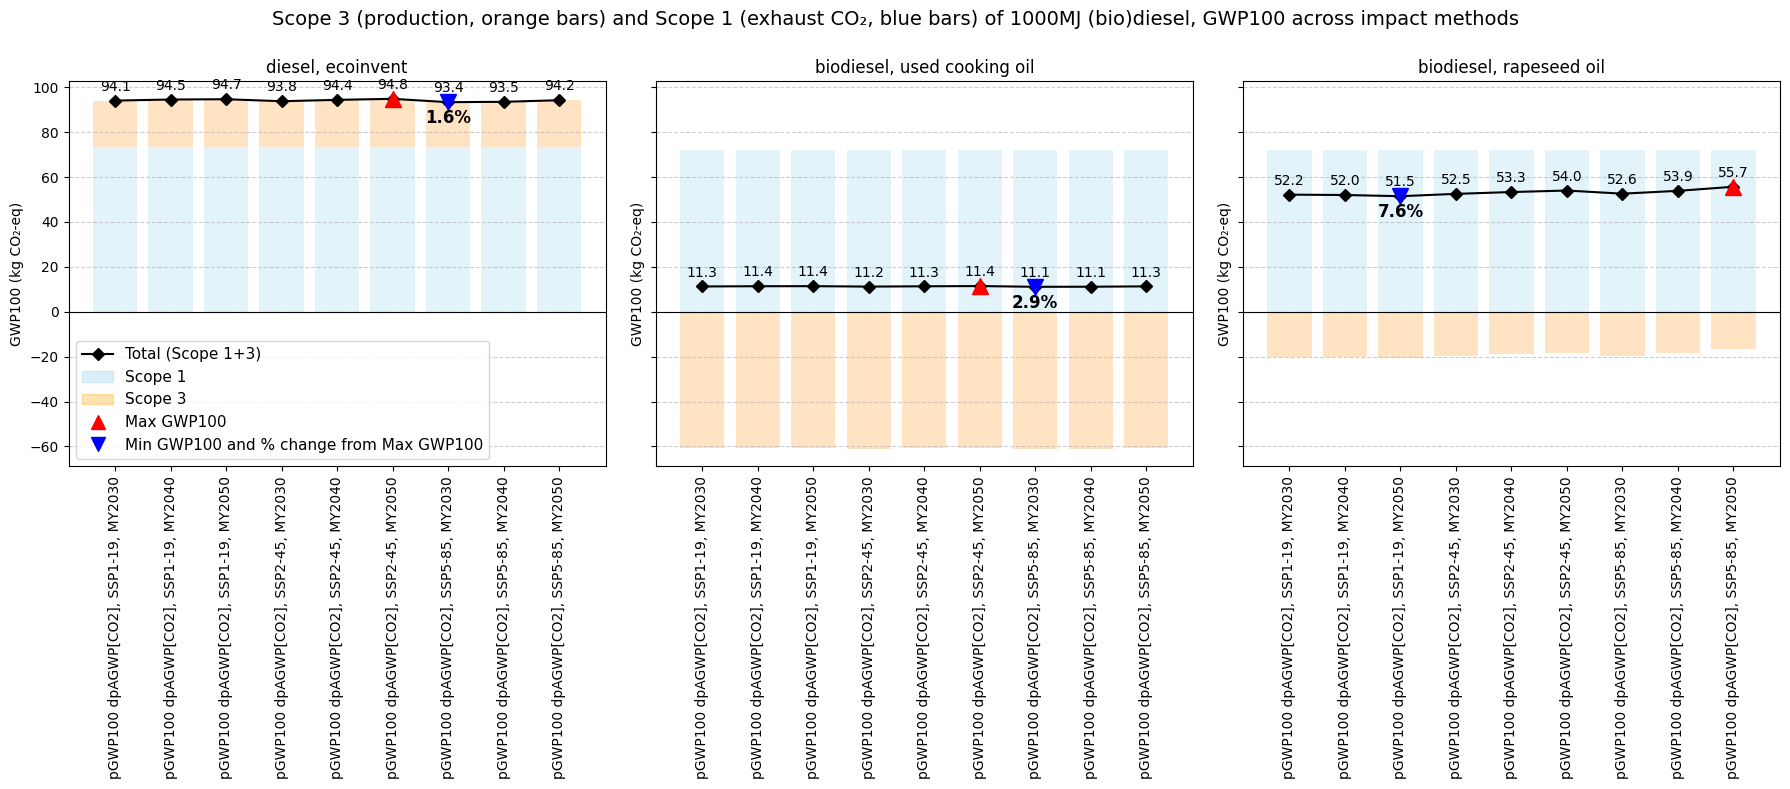

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(18, 8), sharey=True)
fuel_types = ['diesel, ecoinvent', 'biodiesel, used cooking oil', 'biodiesel, rapeseed oil']
colors = {'scope1': 'skyblue', 'scope3': 'darkorange', 'total': 'black'}

for i, fuel in enumerate(fuel_types):
    scope1 = df[(fuel, 'scope 1')]
    scope3 = df[(fuel, 'scope 3')]
    total = scope1 + scope3

    # Transparent bars
    axs[i].bar(df.index, scope1, color=colors['scope1'], alpha=0.236)
    bottom = scope1.where(scope3 >= 0, 0)
    axs[i].bar(df.index, scope3, bottom=bottom, color=colors['scope3'], alpha=0.236)

    # Line + markers for total
    axs[i].plot(df.index, total, color=colors['total'], marker='D', linestyle='-', label='Total (Scope 1+3)')

    # Max and min points
    max_idx = total.idxmax()
    min_idx = total.idxmin()
    max_val = total[max_idx]
    min_val = total[min_idx]
    percent_diff = 100 * (max_val - min_val) / abs(max_val)

    # Red marker for max
    axs[i].plot(max_idx, max_val, marker='^', color='red', markersize=11)
    # Blue marker for min + annotation
    axs[i].plot(min_idx, min_val, marker='v', color='blue', markersize=11)
    axs[i].annotate(f"{percent_diff:.1f}%", xy=(min_idx, min_val),
                    xytext=(0, -15), textcoords='offset points', ha='center',
                    fontsize=12, color='black', fontweight='bold')

    # data label
    for x in df.index:
        y = total[x]
        axs[i].text(x, y + 3, f"{y:.1f}", ha='center', va='bottom', fontsize=10, rotation=0)
        
    axs[i].set_title(fuel, fontsize = 12)
    axs[i].tick_params(axis='x', rotation=90)
    axs[i].set_ylabel("GWP100 (kg CO₂-eq)")
    axs[i].axhline(0, color='black', linewidth=0.8)
    axs[i].grid(True, axis='y', linestyle='--', alpha=0.6)



legend_elements = [
    mlines.Line2D([], [], color='black', marker='D', linestyle='-', label='Total (Scope 1+3)'),
    mpatches.Patch(color='skyblue', alpha=0.3, label=r'Scope 1'), # (only CO$_2$, lack of CH$_4$/N$_2$O for biodiesel)'),
    mpatches.Patch(color='orange', alpha=0.3, label='Scope 3'), # (process from ecoinvent / premise)'),
    mlines.Line2D([], [], color='red', marker='^', linestyle='None', markersize=10, label='Max GWP100'),
    mlines.Line2D([], [], color='blue', marker='v', linestyle='None', markersize=10, label='Min GWP100 and % change from Max GWP100'),
]

axs[0].legend(handles=legend_elements, loc='lower left', fontsize=11)

plt.suptitle("Scope 3 (production, orange bars) and Scope 1 (exhaust CO₂, blue bars) of 1000MJ (bio)diesel, GWP100 across impact methods", fontsize = 14)
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig("fig_output/pgWPvsGWP_Scope1and3_3diesel_barlineplot_dpCO2.png")
plt.show()

### PLOT final scope 1 + 3 , fixed CO2 approach

In [11]:
# for plot with fixed CO2, we only use pGWP100 with the fixed CO2 
df = df[~df.index.str.contains("dpAGWP")]

### adding Scope 1 + 3 for each fuel, for data label 
df_total = pd.DataFrame(index=df.index)
for fuel in ['diesel, ecoinvent', 'biodiesel, used cooking oil', 'biodiesel, rapeseed oil']:
    df_total[fuel] = df[(fuel, 'scope 1')] + df[(fuel, 'scope 3')]

df_total

,"diesel, ecoinvent","biodiesel, used cooking oil","biodiesel, rapeseed oil"
premise GWP100,95.504023,11.593456,59.761830
"pGWP100 fixed AGWP[CO2], SSP1-19, MY2030",97.038386,2.431007,49.313685
"pGWP100 fixed AGWP[CO2], SSP1-19, MY2040",97.336138,3.298429,49.363800
"pGWP100 fixed AGWP[CO2], SSP1-19, MY2050",97.603539,2.956003,48.615749
"pGWP100 fixed AGWP[CO2], SSP2-45, MY2030",96.195888,3.945500,50.264854
"pGWP100 fixed AGWP[CO2], SSP2-45, MY2040",95.504741,8.111763,52.433755
"pGWP100 fixed AGWP[CO2], SSP2-45, MY2050",94.763223,11.738066,54.186857
"pGWP100 fixed AGWP[CO2], SSP5-85, MY2030",95.360432,4.968413,50.727658
"pGWP100 fixed AGWP[CO2], SSP5-85, MY2040",93.593845,10.941036,53.903044
"pGWP100 fixed AGWP[CO2], SSP5-85, MY2050",92.250033,17.184281,57.408968


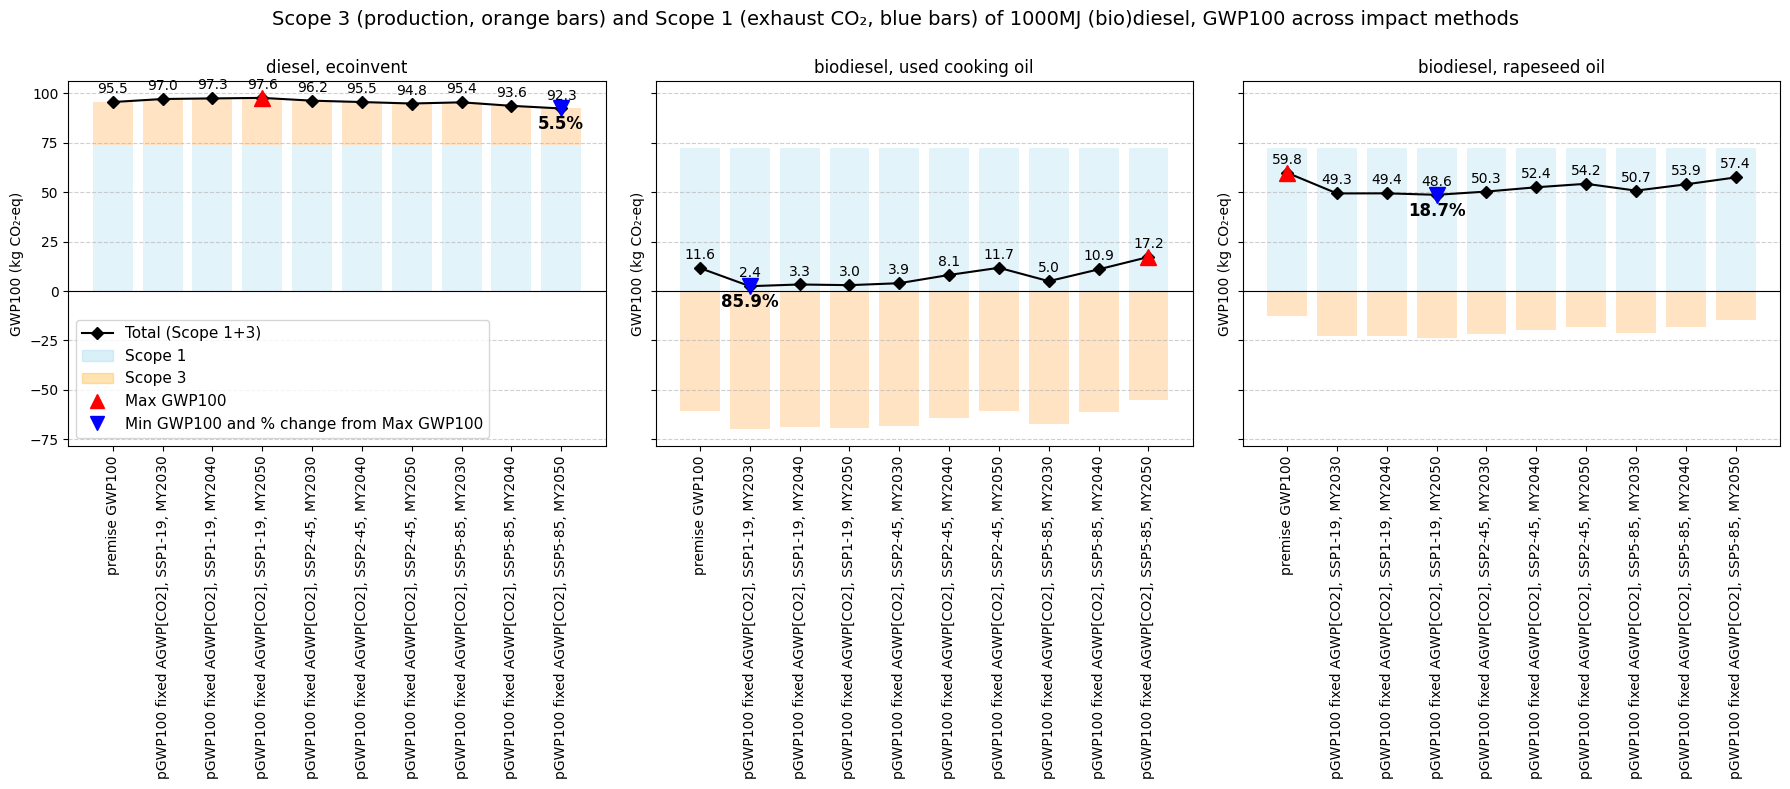

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(18, 8), sharey=True)
fuel_types = ['diesel, ecoinvent', 'biodiesel, used cooking oil', 'biodiesel, rapeseed oil']
colors = {'scope1': 'skyblue', 'scope3': 'darkorange', 'total': 'black'}

for i, fuel in enumerate(fuel_types):
    scope1 = df[(fuel, 'scope 1')]
    scope3 = df[(fuel, 'scope 3')]
    total = scope1 + scope3

    # Transparent bars
    axs[i].bar(df.index, scope1, color=colors['scope1'], alpha=0.236)
    bottom = scope1.where(scope3 >= 0, 0)
    axs[i].bar(df.index, scope3, bottom=bottom, color=colors['scope3'], alpha=0.236)

    # Line + markers for total
    axs[i].plot(df.index, total, color=colors['total'], marker='D', linestyle='-', label='Total (Scope 1+3)')

    # Max and min points
    max_idx = total.idxmax()
    min_idx = total.idxmin()
    max_val = total[max_idx]
    min_val = total[min_idx]
    percent_diff = 100 * (max_val - min_val) / abs(max_val)

    # Red marker for max
    axs[i].plot(max_idx, max_val, marker='^', color='red', markersize=11)
    # Blue marker for min + annotation
    axs[i].plot(min_idx, min_val, marker='v', color='blue', markersize=11)
    axs[i].annotate(f"{percent_diff:.1f}%", xy=(min_idx, min_val),
                    xytext=(0, -15), textcoords='offset points', ha='center',
                    fontsize=12, color='black', fontweight='bold')

    # data label
    for x in df.index:
        y = total[x]
        axs[i].text(x, y + 3, f"{y:.1f}", ha='center', va='bottom', fontsize=10, rotation=0)
        
    axs[i].set_title(fuel, fontsize = 12)
    axs[i].tick_params(axis='x', rotation=90)
    axs[i].set_ylabel("GWP100 (kg CO₂-eq)")
    axs[i].axhline(0, color='black', linewidth=0.8)
    axs[i].grid(True, axis='y', linestyle='--', alpha=0.6)



legend_elements = [
    mlines.Line2D([], [], color='black', marker='D', linestyle='-', label='Total (Scope 1+3)'),
    mpatches.Patch(color='skyblue', alpha=0.3, label=r'Scope 1'), # (only CO$_2$, lack of CH$_4$/N$_2$O for biodiesel)'),
    mpatches.Patch(color='orange', alpha=0.3, label='Scope 3'), # (process from ecoinvent / premise)'),
    mlines.Line2D([], [], color='red', marker='^', linestyle='None', markersize=10, label='Max GWP100'),
    mlines.Line2D([], [], color='blue', marker='v', linestyle='None', markersize=10, label='Min GWP100 and % change from Max GWP100'),
]

axs[0].legend(handles=legend_elements, loc='lower left', fontsize=11)

plt.suptitle("Scope 3 (production, orange bars) and Scope 1 (exhaust CO₂, blue bars) of 1000MJ (bio)diesel, GWP100 across impact methods", fontsize = 14)
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig("fig_output/pgWPvsGWP_Scope1and3_3diesel_barlineplot_fixedCO2.png")
plt.show()


# data source [from gov.uk, diff CO2 EF for diesel/biodiesel, can't seperate CH4/N2O for biodiesel]

https://www.gov.uk/government/publications/greenhouse-gas-reporting-conversion-factors-2025

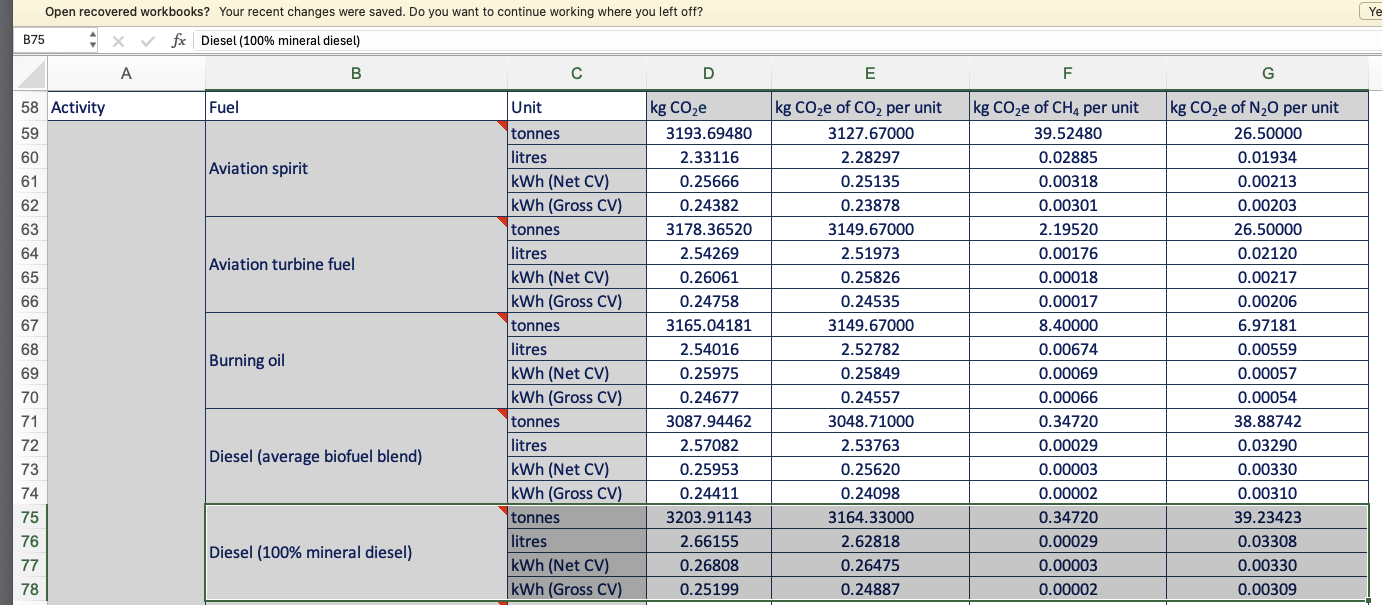

only CH4 and N2O -> CO2e, but no data on CH4/N2O seperately, so we can't model CH4/N2O with its own dpCFs
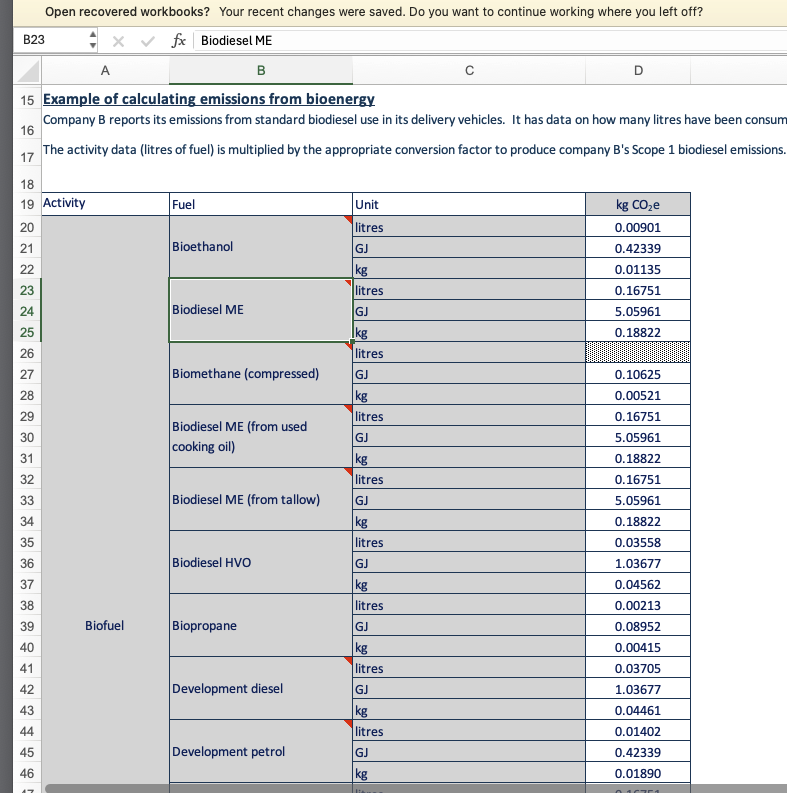

"outside of scope" sheet  ->> the bio-CO2 released during combustion :  
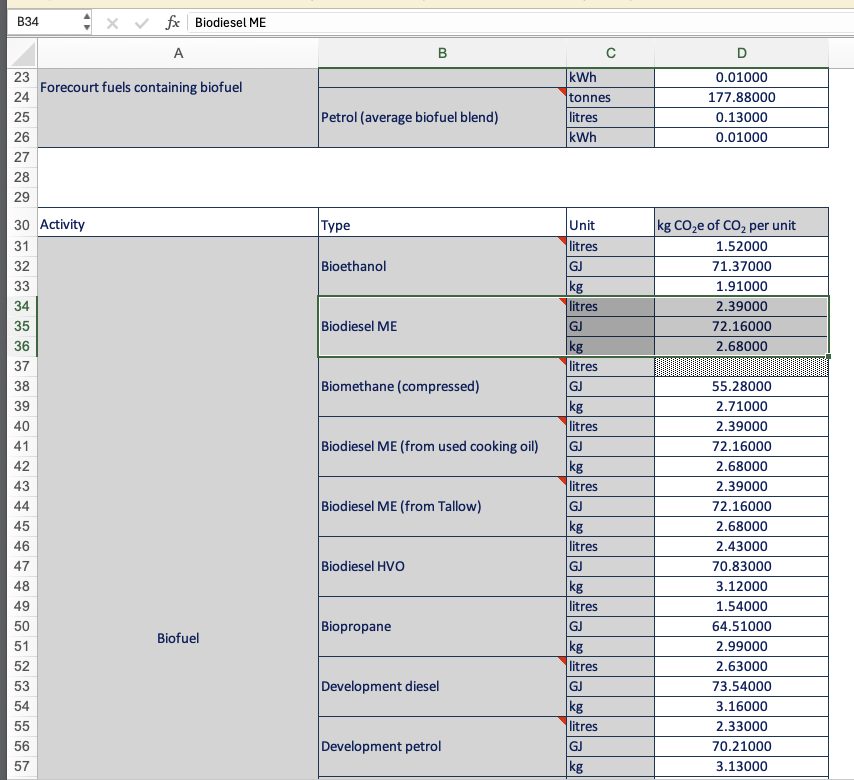

### assume SAME N2O / CH4 EFs for diesel/biodiesel per NRCAN, which is the EF used in the garbage truck case: 

""" 
from NRCAN: 
Heavy-duty Diesel Vehicles (HDDVs)	Emission Factors (g/L fuel)	CO2 CH4 N2O 		
Advanced Control	2,680.50	a	0.11	i	0.151
Moderate Control	2,680.50	a	0.14	f	0.082

assuming 0.84	kg per liter diesel, regardless if bio-diesel or conventional diesel, as for the F2_fuel_diesel module 
https://docs.google.com/spreadsheets/d/1_qotcARay-UyygXMX8Ha16aR90uKgEH81npOohgFgcg/edit#gid=654492837 
""" 

v2030_ef = {
    'exh_CO2': 2.68 / 0.84  ,
    'exh_CH4': 0.11 / 1000 / 0.84 ,
    'exh_N2O': 0.082/ 1000 / 0.84 
}
